# Bài bập 3.26
Cho hàm số: f(x)=x2−4x+5
Thực hiện Gradient Descent với:
•	Điểm khởi tạo x(0)=5
•	Learning rate η=0.2
Yêu cầu:
1.	Tính đạo hàm f′(x).
2.	Thực hiện 4 bước cập nhật. 
3.	Tính giá trị hàm số tại mỗi bước. 
4.	Nhận xét sự hội tụ của thuật toán.


In [43]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


In [44]:
def grad(x):
    return 2 * x - 4

def cost(x):
    return x**2 - 4 * x + 5

def myGD1(x0, eta):
    x = [x0]

    for it in range(4):
        x_new = x[-1] - eta * grad(x[-1])
        x.append(x_new)

        print("Step %d: x = %.4f, cost = %.4f"
              % (it + 1, x_new, cost(x_new)))

        if abs(grad(x_new)) < 1e-3:
            break

    return x
x = myGD1(5, 0.2)

Step 1: x = 3.8000, cost = 4.2400
Step 2: x = 3.0800, cost = 2.1664
Step 3: x = 2.6480, cost = 1.4199
Step 4: x = 2.3888, cost = 1.1512


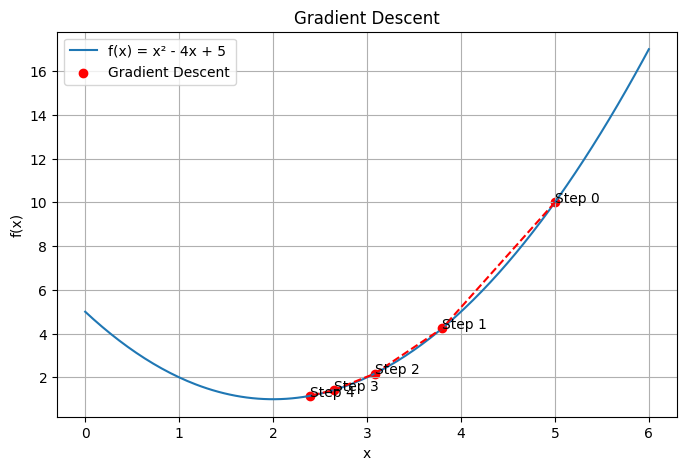

In [45]:

x_plot = np.linspace(0, 6, 200)
y_plot = cost(x_plot)
plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, label="f(x) = x² - 4x + 5")
y = [cost(i) for i in x]
plt.scatter(x, y, color="red", label="Gradient Descent")
plt.plot(x, y, "--", color="red")
for i in range(len(x)):
    plt.annotate(f"Step {i}", (x[i], y[i]))

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent")
plt.grid(True)
plt.legend()

plt.show()

# 3.27 Cho: w=[1, 2, -10]T, x=[3, 4, 1]T và điểm dữ liệu đã thêm bias.
Sử dụng phương pháp Perceptron:
1.	Tính wTx. 
2.	Xác định nhãn dự đoán của điểm dữ liệu. 
3.	Nếu nhãn thực tế là y=−1, điểm dữ liệu có bị phân lớp sai không?

In [46]:
w = np.array([[1], [2], [-10]])
x = np.array([[3], [4], [1]])

wx = w.T @ x

if wx >0:
    item = 1
else:
    item = -1
print( "Nhãn dự doán là ", item)

y = -1
if item != y:
    print ("nhãn bị phân lớp sai")
else:
    print ("nhãn được phân lớp đúng")

Nhãn dự doán là  1
nhãn bị phân lớp sai


# 3.28 Cho: w=[−2, 1, 0]T, x=[2, 3, 1]T,  y=1, trong đó, x đã thêm bias.
Sử dụng phương pháp Perceptron:
1.	Kiểm tra mẫu có bị phân lớp sai hay không. 
2.	Nếu sai, thực hiện một bước cập nhật Perceptron. 
3.	Tính lại giá trị wTx sau cập nhật.

In [47]:
w = np.array([[-2], [1], [0]])
x = np.array([[2], [3], [1]])

y = 1
eta = 1

wx = w.T @ x
print("wT * X = ", wx)

if wx > 0:
    item = 1
else:
    item = -1
print("Nhãn dự đoán là ", item)

if item != y:
    print("Do khác y nên nhãn bị phân lớp sai")
    w = w + eta * y * x
    print("Cập nhật w = ", w)
else:
    print("nhãn được phân lớp đúng")

wx_new = w.T @ x
print("wT * X mới = ", wx_new)

wT * X =  [[-1]]
Nhãn dự đoán là  -1
Do khác y nên nhãn bị phân lớp sai
Cập nhật w =  [[0]
 [4]
 [1]]
wT * X mới =  [[13]]


# 3.29 Viết code 
để xây dựng lớp Perceptron có hàm fit để huấn luyện mô hình 
và hàm predict để dự báo nhãn của dữ liệu mới.

In [48]:

df = pd.read_csv("Crop.csv")

data = df[df["label"].isin(["rice", "maize"])]

X = data[["temperature", "humidity"]].values
X = np.c_[np.ones(X.shape[0]), X]

y = np.where(data["label"] == "rice", 1, -1)


class Perceptron:

    def __init__(self):
        self.w = None

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])

        while True:
            error = 0

            for i in range(len(X)):
                x_i = X[i]
                y_i = y[i]

                z = self.w @ x_i

                if z >= 0:
                    prediction = 1
                else:
                    prediction = -1

                if prediction != y_i:
                    self.w = self.w + y_i * x_i
                    error += 1

            if error == 0:
                break

        return self

    def predict(self, X):
        predictions = []

        for x_i in X:
            z = self.w @ x_i

            if z >= 0:
                prediction = 1
            else:
                prediction = -1

            predictions.append(prediction)

        return np.array(predictions)


model = Perceptron()
model.fit(X, y)

print("Trọng số w:", model.w)

X_new = np.array([
    [1, 25, 80]
])

prediction = model.predict(X_new)

if prediction[0] == 1:
    print("Dự đoán: rice")
else:
    print("Dự đoán: maize")

Trọng số w: [-45105.           -550.3612478     745.38115238]
Dự đoán: rice


### 3.30 Chọn một tập dữ liệu để thực hiện bài toán phân lớp nhị phân (ví dụ, tập dữ liệu về giao dịch có là gian lận hay không, …). Sử dụng phương pháp Perceptron để xây dựng mô hình dự báo đạt kết quả tốt nhất theo các độ đo Accuracy, Precision, Recall, F1-score.

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Số mẫu train:", len(X_train))
print("Số mẫu test:", len(X_test))

Số mẫu train: 160
Số mẫu test: 40


In [50]:
model = Perceptron()

model.fit(X_train, y_train)

print("Trọng số w:", model.w)

Trọng số w: [-25737.           -245.04147111    407.33117796]


In [51]:
y_pred = model.predict(X_test)

print("Kết quả dự đoán:", y_pred)
print("Kết quả thực tế:", y_test)

Kết quả dự đoán: [-1  1  1  1 -1  1 -1  1  1 -1  1  1 -1  1 -1 -1  1 -1 -1  1 -1  1  1  1
  1  1  1 -1  1 -1  1 -1 -1 -1 -1 -1 -1 -1  1 -1]
Kết quả thực tế: [-1  1  1  1 -1  1 -1  1  1 -1  1  1 -1  1 -1 -1  1 -1 -1  1 -1  1  1  1
  1  1  1 -1  1 -1  1 -1 -1 -1 -1 -1 -1 -1  1 -1]


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0


In [53]:
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-score : {f1 * 100:.2f}%")

Accuracy : 100.00%
Precision: 100.00%
Recall   : 100.00%
F1-score : 100.00%
